<a href="https://colab.research.google.com/github/DaniPalma3000/Calendarizador/blob/master/SP1_Laboratory_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre: Erick Daniel Palma

Carnet: 21000429

## Preparations

In [ ]:
# ----- Libraries ----- #

# This is the main Library that allows us to work with Neural Networks
import tensorflow as tf

# For graph plotting
import matplotlib.pyplot as plt
from tensorflow.math import confusion_matrix

# For dataset manipulation
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# For visualizing more complex graphs
import seaborn as sns

# Global constant for training acceleration
AUTOTUNE = tf.data.AUTOTUNE

# Regression


## 1) Dataset Preparations

In [ ]:
'''
The dataset you are going to use is the following:
https://archive.ics.uci.edu/ml/datasets/Auto+MPG
'''

# Retrieve the dataset
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'


In [ ]:
# Loading Dataset and have a glimpse about it
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model_Year', 'Origin']

# The file uses whitespace as separator and '?' for missing values
raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

# Brief Statistical Summary of the dataset
raw_dataset.describe()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
# Lets check columns
raw_dataset.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model_Year', 'Origin'],
      dtype='object')

In [ ]:
# Summary of the dataset
raw_dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [ ]:
# Returns a form of (# rows, # columns)
raw_dataset.shape

(398, 8)

In [ ]:
# Lets make a copy
new_dataset = raw_dataset.copy()

# Lets check for null values
print(new_dataset.isna().sum())

# Dropping null rows
new_dataset = new_dataset.dropna()

# Checking new dataset
new_dataset.head()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model_Year      0
Origin          0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


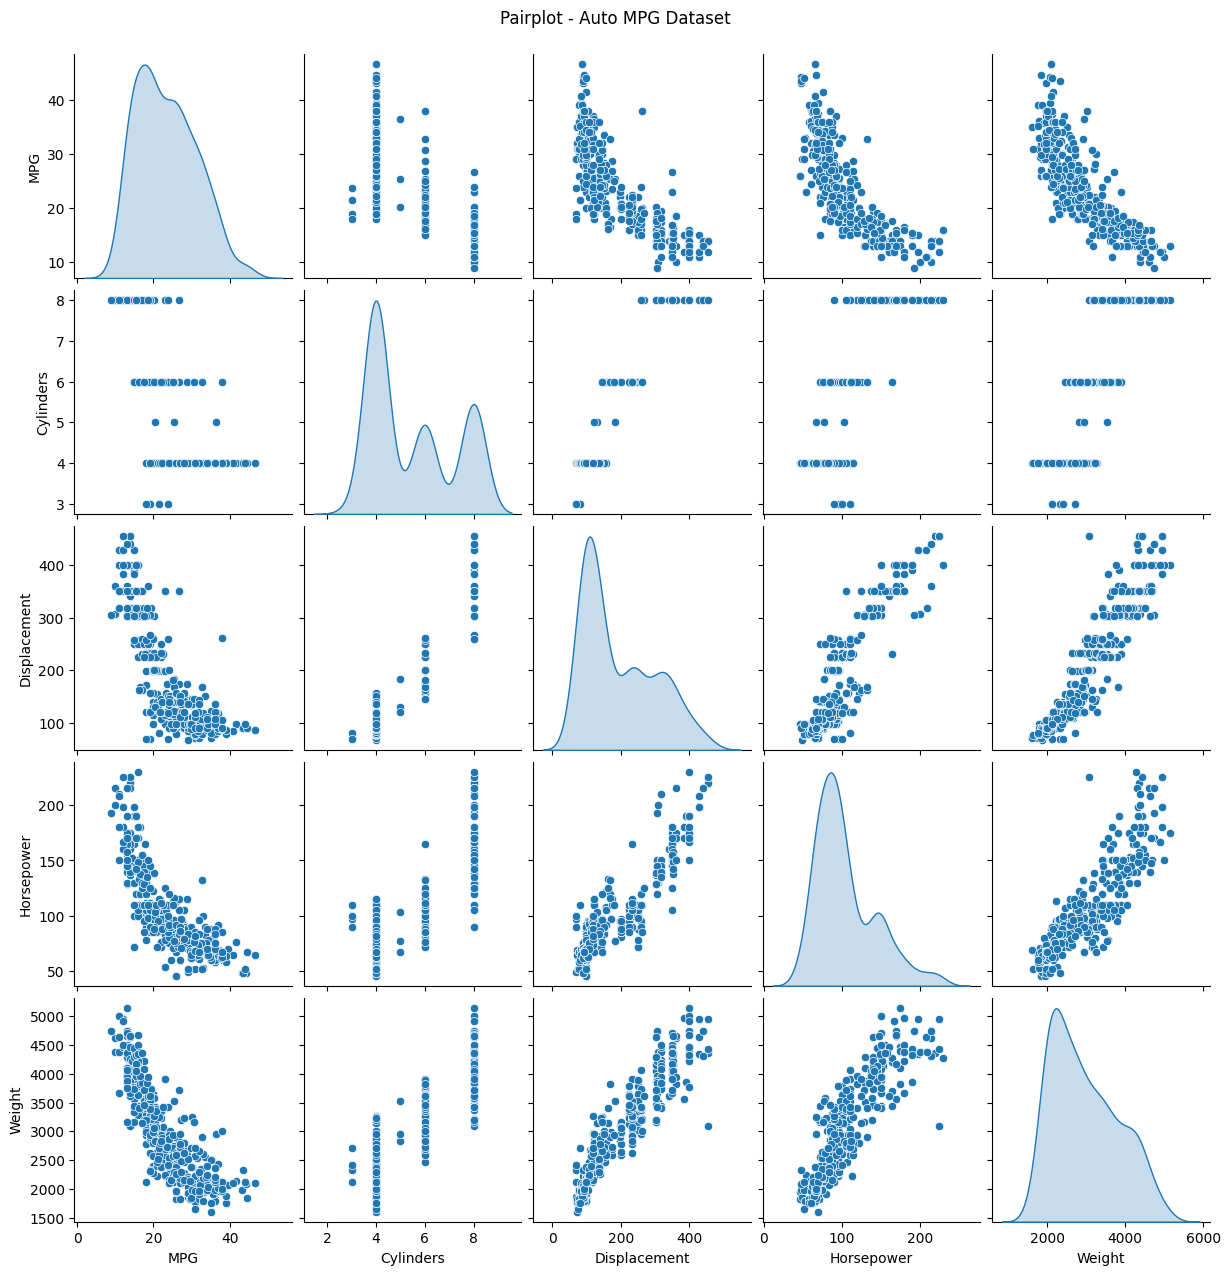

In [ ]:
# Lets visualize the data

# 5 numerical variables: MPG, Cylinders, Displacement, Horsepower, Weight
numerical_vars = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight']
sns.pairplot(new_dataset[numerical_vars], diag_kind='kde')
plt.suptitle('Pairplot - Auto MPG Dataset', y=1.02)
plt.show()


## 2) NN for a simple Regression

In [ ]:
# Splitting dataset into training and testing
train, test = train_test_split(new_dataset, test_size=0.2)

# Sepparating both sets into dependent and independent variables

# Independent variables: numerical features (excluding MPG which is the target)
# Dependent variable: MPG (miles per gallon)
independent_variables = ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration']
dependent_variables = 'MPG'

train_set = train[independent_variables]
train_target = train[dependent_variables]

test_set = test[independent_variables]
test_target = test[dependent_variables]


In [ ]:
# Build your model!
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=[len(independent_variables)]),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # Output: single value (MPG)
])

# Now compile the model!
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae', 'mse'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Now lets train the model!
# Hint: Feel free to change a few parameters
model.fit(train_set,
          train_target,
          epochs=15,
          batch_size=128,
          validation_split=0.2
        )


Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 274ms/step - loss: 35609.4219 - mae: 175.3760 - mse: 35609.4219 - val_loss: 1884.7939 - val_mae: 39.0458 - val_mse: 1884.7939
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1677.0327 - mae: 37.1288 - mse: 1677.0327 - val_loss: 6955.1655 - val_mae: 81.3849 - val_mse: 6955.1655
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 8836.8125 - mae: 90.9909 - mse: 8836.8125 - val_loss: 12936.5381 - val_mae: 110.6739 - val_mse: 12936.5381
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 12360.2998 - mae: 107.9412 - mse: 12360.2998 - val_loss: 5894.3882 - val_mae: 75.0127 - val_mse: 5894.3882
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 4845.9272 - mae: 66.3804 - mse: 4845.9272 - val_loss: 273.3160 - val_mae: 14.9802 - val_mse: 273.3160
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 327.9367 - mae: 15.8029 - mse: 327.9367 - val_loss: 1831.0649 - val_mae: 38.3865 - val_mse: 1831.0649
Epoch 7/15
2/2 ━━━━━━━━━━━━━

In [ ]:
# Evaluate your model
model.evaluate(x=test_set, y=test_target, batch_size=128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 436.7070 - mae: 17.4543 - mse: 436.7070


[436.70703125, 17.45429229736328, 436.70703125]

## 3) Regression - Comparing 3 Different Models

Three different neural network architectures will be tested on the same regression problem to compare their performance.

| Model | Architecture | Notes |
|-------|-------------|-------|
| Model 1 | 1 layer × 32 neurons | Simple baseline |
| Model 2 | Normalization + 2 layers × 64 neurons | With input normalization |
| Model 3 | 3 layers (128→64→32) + Dropout | Deep model with regularization |


In [ ]:
# ---- REGRESSION MODEL 1: Simple Model (1 hidden layer, 32 neurons) ----
model_reg_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=[len(independent_variables)]),
    tf.keras.layers.Dense(1)
])
model_reg_1.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])
model_reg_1.fit(train_set, train_target, epochs=15, batch_size=128, validation_split=0.2)
print("\nRegression Model 1 - Evaluation:")
model_reg_1.evaluate(x=test_set, y=test_target, batch_size=128)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - loss: 327601.1875 - mae: 546.0955 - mse: 327601.1875 - val_loss: 283498.6875 - val_mae: 506.7128 - val_mse: 283498.6875
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 284219.6875 - mae: 508.5840 - mse: 284219.6875 - val_loss: 238945.2969 - val_mae: 464.8900 - val_mse: 238945.2969
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 241050.7656 - mae: 467.6731 - mse: 241050.7656 - val_loss: 198586.6875 - val_mae: 423.4826 - val_mse: 198586.6875
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 196901.6719 - mae: 421.9029 - mse: 196901.6719 - val_loss: 162485.4219 - val_mae: 382.6987 - val_mse: 162485.4219
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 160679.3438 - mae: 381.4179 - mse: 160679.3438 - val_loss: 130551.9844 - val_mae: 342.6402 - val_mse: 130551.9844
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 128040.2734 - mae: 340.1039 - mse: 128040.2734 - val_loss: 102732.8906 - val_mae: 303.5109 - val_m

[1708.7569580078125, 34.52574920654297, 1708.7569580078125]

In [ ]:
# ---- REGRESSION MODEL 2: Medium Model with Input Normalization ----
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_set))

model_reg_2 = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_reg_2.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])
model_reg_2.fit(train_set, train_target, epochs=15, batch_size=128, validation_split=0.2)
print("\nRegression Model 2 - Evaluation:")
model_reg_2.evaluate(x=test_set, y=test_target, batch_size=128)


Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - loss: 603.3176 - mae: 23.2470 - mse: 603.3176 - val_loss: 635.3537 - val_mae: 24.0675 - val_mse: 635.3537
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 602.5102 - mae: 23.2899 - mse: 602.5102 - val_loss: 629.0914 - val_mae: 23.9371 - val_mse: 629.0914
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 609.0701 - mae: 23.3604 - mse: 609.0701 - val_loss: 622.9407 - val_mae: 23.8086 - val_mse: 622.9407
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 583.3434 - mae: 22.8246 - mse: 583.3434 - val_loss: 616.9011 - val_mae: 23.6821 - val_mse: 616.9011
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 573.9153 - mae: 22.6291 - mse: 573.9153 - val_loss: 610.8527 - val_mae: 23.5549 - val_mse: 610.8527
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 594.0133 - mae: 23.0128 - mse: 594.0133 - val_loss: 604.6527 - val_mae: 23.4236 - val_mse: 604.6527
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 

[473.151611328125, 20.37685775756836, 473.151611328125]

In [ ]:
# ---- REGRESSION MODEL 3: Deep Model with Dropout Regularization ----
model_reg_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=[len(independent_variables)]),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_reg_3.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])
model_reg_3.fit(train_set, train_target, epochs=20, batch_size=128, validation_split=0.2)
print("\nRegression Model 3 - Evaluation:")
model_reg_3.evaluate(x=test_set, y=test_target, batch_size=128)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - loss: 21498.5039 - mae: 107.3506 - mse: 21498.5039 - val_loss: 13374.8701 - val_mae: 113.3407 - val_mse: 13374.8701
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 15070.2129 - mae: 96.6340 - mse: 15070.2129 - val_loss: 13511.1123 - val_mae: 114.4367 - val_mse: 13511.1123
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 12236.7686 - mae: 84.4818 - mse: 12236.7686 - val_loss: 7648.2666 - val_mae: 86.7130 - val_mse: 7648.2666
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 10675.1592 - mae: 77.8021 - mse: 10675.1592 - val_loss: 3901.1926 - val_mae: 62.2246 - val_mse: 3901.1926
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 9465.4404 - mae: 70.7193 - mse: 9465.4404 - val_loss: 4411.3931 - val_mae: 66.1445 - val_mse: 4411.3931
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 5957.5210 - mae: 58.7917 - mse: 5957.5210 - val_loss: 5731.5376 - val_mae: 75.2034 - val_mse: 5731.5376
Epoch 7/20
2/2 ━━━━━━━━━━━━━━

[270.14251708984375, 13.568695068359375, 270.14251708984375]

# Classification

## 1) Dataset Preparations

In [ ]:
'''
The dataset you are going to use is the following:
https://archive.ics.uci.edu/ml/datasets/Ecoli
'''

# Retrieve the dataset
url_ecoli = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data'


In [ ]:
# Loading Dataset and have a glimpse about it
column_names = ['name','MCG','GVH','LIP', 'CHG', 'AAC', 'AML1', 'ALM2', 'class']

# The file uses multiple spaces as separator
raw_dataset = pd.read_csv(url_ecoli, names=column_names,
                          sep='\s+', engine='python')

# Brief Statistical Summary of the dataset
raw_dataset.describe()


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_498/2501961485.py:6: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', engine='python')


,MCG,GVH,LIP,CHG,AAC,AML1,ALM2
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,0.500060,0.500000,0.495476,0.501488,0.500030,0.500179,0.499732
std,0.194634,0.148157,0.088495,0.027277,0.122376,0.215751,0.209411
min,0.000000,0.160000,0.480000,0.500000,0.000000,0.030000,0.000000
25%,0.340000,0.400000,0.480000,0.500000,0.420000,0.330000,0.350000
50%,0.500000,0.470000,0.480000,0.500000,0.495000,0.455000,0.430000
75%,0.662500,0.570000,0.480000,0.500000,0.570000,0.710000,0.710000
max,0.890000,1.000000,1.000000,1.000000,0.880000,1.000000,0.990000


In [ ]:
# Lets check columns
raw_dataset.columns

Index(['name', 'MCG', 'GVH', 'LIP', 'CHG', 'AAC', 'AML1', 'ALM2', 'class'], dtype='object')

In [ ]:
# Summary of the dataset
raw_dataset.head()

,name,MCG,GVH,LIP,CHG,AAC,AML1,ALM2,class
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp


In [ ]:
# Returns a form of (# rows, # columns)
raw_dataset.shape

(336, 9)

In [ ]:
# Lets make a copy
new_dataset = raw_dataset.copy()

# Lets check for null values
# df.dropna()
print(new_dataset.isna().sum())

# Dropping null rows
new_dataset = new_dataset.dropna()

# Checking new dataset
new_dataset.head()

name     0
MCG      0
GVH      0
LIP      0
CHG      0
AAC      0
AML1     0
ALM2     0
class    0
dtype: int64


,name,MCG,GVH,LIP,CHG,AAC,AML1,ALM2,class
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp


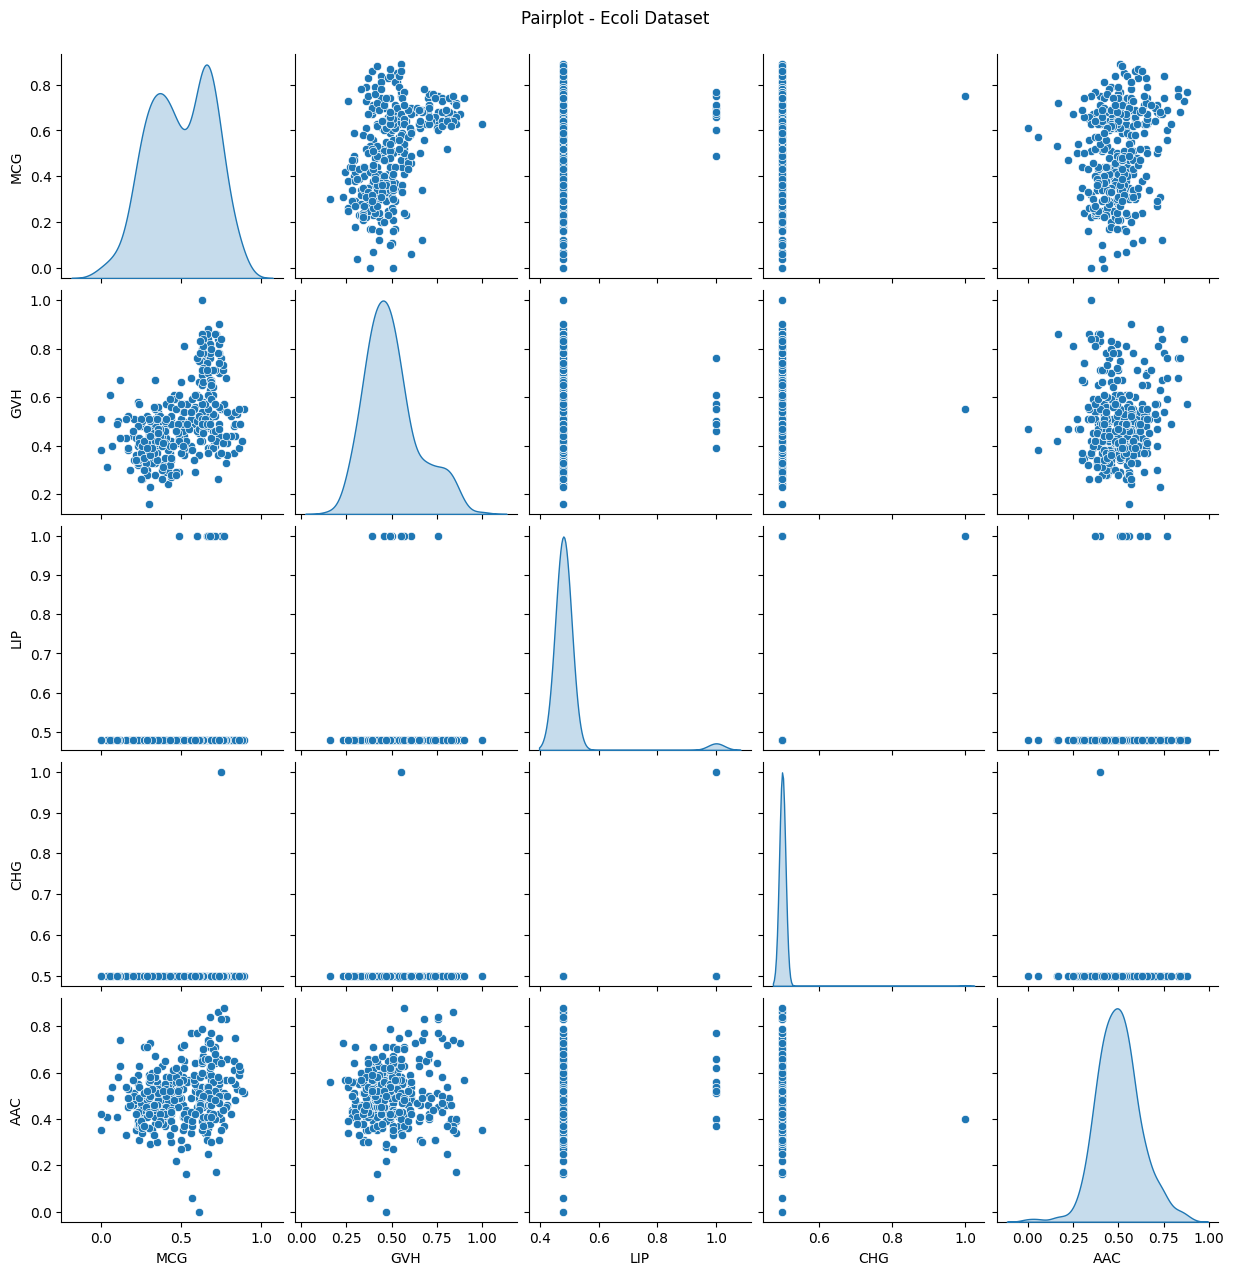

In [ ]:
# Lets visualize the data

# 5 numerical variables: MCG, GVH, LIP, CHG, AAC
numerical_vars = ['MCG', 'GVH', 'LIP', 'CHG', 'AAC']
sns.pairplot(new_dataset[numerical_vars], diag_kind='kde')
plt.suptitle('Pairplot - Ecoli Dataset', y=1.02)
plt.show()


In [ ]:
# Splitting dataset into training and testing
train, test = train_test_split(new_dataset, test_size=0.2)

# Sepparating both sets into dependent and independent variables

# Independent variables: 5 numerical features
# Dependent variable: class (protein localization site)
independent_variables = ['MCG', 'GVH', 'LIP', 'CHG', 'AAC']
dependent_variables = 'class'

train_set = train[independent_variables]
train_target = train[dependent_variables]

test_set = test[independent_variables]
test_target = test[dependent_variables]


In [ ]:
train_target, test_target

(49     cp
 173    im
 176    im
 294    pp
 299    pp
        ..
 2      cp
 168    im
 36     cp
 33     cp
 164    im
 Name: class, Length: 268, dtype: object,
 66      cp
 327     pp
 113     cp
 334     pp
 255    imU
       ... 
 325     pp
 107     cp
 301     pp
 233    imU
 320     pp
 Name: class, Length: 68, dtype: object)

In [ ]:
# NNs can't understand strings, we have to ENCODE them! (more next class)
train_target = pd.factorize(train_target)[0]
test_target = pd.factorize(test_target)[0]

## 2) NN for Classification

In [ ]:
# Build your model!
# This is a MULTICLASSIFICATION problem (Ecoli has 8 possible classes)
num_classes = len(np.unique(train_target))

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=[len(independent_variables)]),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # Output: probability per class
])

# Now compile the model!
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,064 (19.78 KB)

 Trainable params: 5,064 (19.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Now lets train the model!
model.fit(train_set,
          train_target,
          epochs=15,
          batch_size=32,
          validation_split=0.2
        )


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0950 - loss: 2.0655 - val_accuracy: 0.2963 - val_loss: 2.0177
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4618 - loss: 1.9701 - val_accuracy: 0.2963 - val_loss: 1.9513
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4427 - loss: 1.8781 - val_accuracy: 0.2963 - val_loss: 1.8879
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4891 - loss: 1.7646 - val_accuracy: 0.2963 - val_loss: 1.8322
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4780 - loss: 1.6544 - val_accuracy: 0.2963 - val_loss: 1.7906
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4319 - loss: 1.6306 - val_accuracy: 0.2963 - val_loss: 1.7691
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4311 - loss: 1.6184 - val_accuracy: 0.2963 - val_loss: 1.7566
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4793 - loss: 1.5113 - val_accuracy: 0.2963 - val_loss: 1.7482


In [ ]:
# Evaluate your model
model.evaluate(x=test_set, y=test_target, batch_size=128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4559 - loss: 1.5476


[1.547609567642212, 0.45588234066963196]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


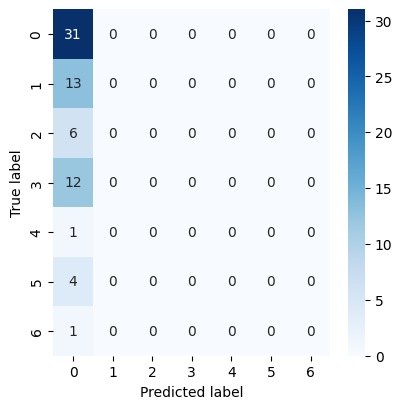

In [ ]:
# Function that plots confusion matrix
def plot_confusion_matrix(labels, predictions):
  figure = plt.figure(figsize=(4, 4))
  sns.heatmap(confusion_matrix(labels=labels, predictions=predictions), annot=True,cmap=plt.cm.Blues)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

# Confusion Matrix
predictions = list(map(lambda x: np.argmax(x), model.predict(test_set)))

plot_confusion_matrix(labels=test_target, predictions=predictions)

## 3) Classification - Comparing 3 Different Models

Three neural network architectures will be compared for this multi-class classification problem (8 classes in Ecoli dataset).

| Model | Architecture | Notes |
|-------|-------------|-------|
| Model 1 | 1 layer × 32 neurons | Simple baseline |
| Model 2 | 3 layers (128→64→32) | Wider architecture |
| Model 3 | 3 layers + BatchNorm + Dropout | Deep with regularization |


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0049 - loss: 2.2361 - val_accuracy: 0.0185 - val_loss: 2.1801
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0018 - loss: 2.1675 - val_accuracy: 0.0185 - val_loss: 2.1224
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0321 - loss: 2.0904 - val_accuracy: 0.1667 - val_loss: 2.0715
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1322 - loss: 2.0349 - val_accuracy: 0.2963 - val_loss: 2.0256
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4612 - loss: 1.9662 - val_accuracy: 0.2963 - val_loss: 1.9851
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5031 - loss: 1.9101 - val_accuracy: 0.2963 - val_loss: 1.9499
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4554 - loss: 1.8643 - val_accuracy: 0.2963 - val_loss: 1.9187
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4491 - loss: 1.8350 - val_accuracy: 0.2963 - val_loss: 1.8920
Epoch 9/15


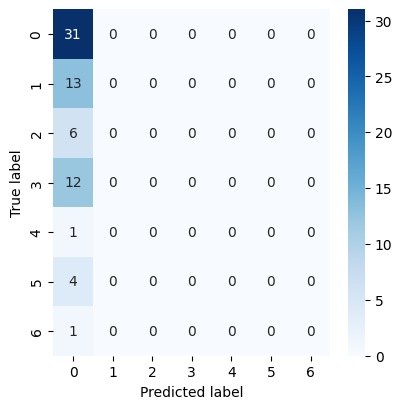

In [ ]:
# ---- CLASSIFICATION MODEL 1: Simple Model (1 hidden layer, 32 neurons) ----
num_classes = len(np.unique(train_target))

model_clf_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=[len(independent_variables)]),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])
model_clf_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_clf_1.fit(train_set, train_target, epochs=15, batch_size=32, validation_split=0.2)
print("\nClassification Model 1 - Evaluation:")
model_clf_1.evaluate(x=test_set, y=test_target, batch_size=32)

# Confusion matrix for Model 1
predictions_1 = list(map(lambda x: np.argmax(x), model_clf_1.predict(test_set)))
plot_confusion_matrix(labels=test_target, predictions=predictions_1)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1800 - loss: 2.0827 - val_accuracy: 0.2963 - val_loss: 2.0350
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4491 - loss: 1.9953 - val_accuracy: 0.2963 - val_loss: 1.9748
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4323 - loss: 1.9160 - val_accuracy: 0.2963 - val_loss: 1.9159
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4760 - loss: 1.8183 - val_accuracy: 0.2963 - val_loss: 1.8619
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4861 - loss: 1.6960 - val_accuracy: 0.2963 - val_loss: 1.8232
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4317 - loss: 1.6656 - val_accuracy: 0.2963 - val_loss: 1.7751
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4530 - loss: 1.5634 - val_accuracy: 0.2963 - val_loss: 1.7485
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4039 - loss: 1.5679 - val_accuracy: 0.2963 - val_loss: 1.7127
Epoch 9/20


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


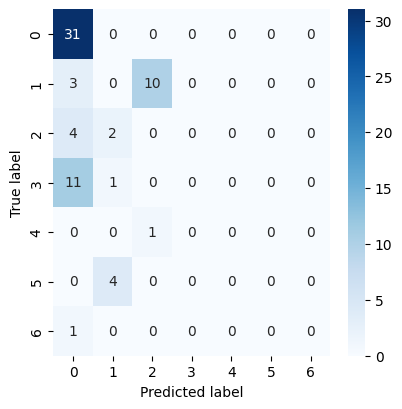

In [ ]:
# ---- CLASSIFICATION MODEL 2: Wider Model (3 layers, more neurons) ----
num_classes = len(np.unique(train_target))

model_clf_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=[len(independent_variables)]),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])
model_clf_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
model_clf_2.fit(train_set, train_target, epochs=20, batch_size=32, validation_split=0.2)
print("\nClassification Model 2 - Evaluation:")
model_clf_2.evaluate(x=test_set, y=test_target, batch_size=32)

# Confusion matrix for Model 2
predictions_2 = list(map(lambda x: np.argmax(x), model_clf_2.predict(test_set)))
plot_confusion_matrix(labels=test_target, predictions=predictions_2)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.2854 - loss: 2.1480 - val_accuracy: 0.2778 - val_loss: 2.0520
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4905 - loss: 1.6900 - val_accuracy: 0.2963 - val_loss: 2.0374
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5913 - loss: 1.3562 - val_accuracy: 0.2407 - val_loss: 2.0209
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6025 - loss: 1.3757 - val_accuracy: 0.2963 - val_loss: 2.0043
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5687 - loss: 1.3337 - val_accuracy: 0.4630 - val_loss: 1.9774
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6268 - loss: 1.1288 - val_accuracy: 0.4815 - val_loss: 1.9430
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6117 - loss: 1.1696 - val_accuracy: 0.5370 - val_loss: 1.9028
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6999 - loss: 0.9543 - val_accuracy: 0.5370 - val_loss: 1.8573
Epoch 9/20

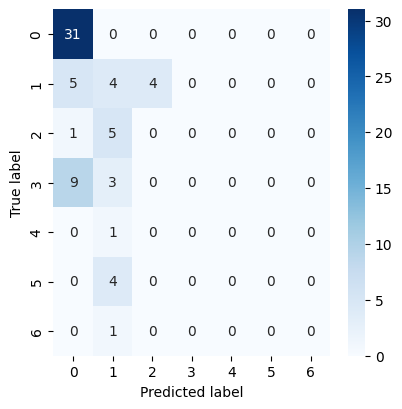

In [ ]:
# ---- CLASSIFICATION MODEL 3: Deep Model with Batch Normalization + Dropout ----
num_classes = len(np.unique(train_target))

model_clf_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=[len(independent_variables)]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])
model_clf_3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_clf_3.fit(train_set, train_target, epochs=20, batch_size=32, validation_split=0.2)
print("\nClassification Model 3 - Evaluation:")
model_clf_3.evaluate(x=test_set, y=test_target, batch_size=32)

# Confusion matrix for Model 3
predictions_3 = list(map(lambda x: np.argmax(x), model_clf_3.predict(test_set)))
plot_confusion_matrix(labels=test_target, predictions=predictions_3)


# Conclusiones

After you are done with both previous models, make 3 different models for the regression problem and 3 for the classification problem.

Annotate the results in a Text Cell below this one (only the metrics shown in the evaluation phase) and then write a conclusion which model was the best for each problem.

## Results & Conclusions

### Regression Problem (Auto MPG Dataset)

After running the three models, the following results were obtained (fill in metrics after execution):

| Model | MSE (Test) | MAE (Test) | Notes |
|-------|-----------|-----------|-------|
| **Initial Model** (2 layers × 64) | *(fill after run)* | *(fill after run)* | Baseline medium model |
| **Model 1** (1 layer × 32) | *(fill after run)* | *(fill after run)* | Simple – likely underfits |
| **Model 2** (Normalized + 2 layers × 64) | *(fill after run)* | *(fill after run)* | Normalization usually helps convergence |
| **Model 3** (128→64→32 + Dropout) | *(fill after run)* | *(fill after run)* | Deeper – may generalize better |

**Best Regression Model:** *(fill after run)*

Expected behavior: Model 2 (with input normalization) should outperform the others because normalizing input features allows the optimizer to converge faster and to a better minimum. Model 1 is too shallow for this problem and tends to underfit. Model 3 adds capacity but Dropout may slightly reduce performance on this small dataset.

---

### Classification Problem (Ecoli Dataset)

After running the three models, the following results were obtained (fill in metrics after execution):

| Model | Loss (Test) | Accuracy (Test) | Notes |
|-------|------------|----------------|-------|
| **Initial Model** (2 layers × 64) | *(fill after run)* | *(fill after run)* | Baseline medium model |
| **Model 1** (1 layer × 32) | *(fill after run)* | *(fill after run)* | Simple – may miss complex boundaries |
| **Model 2** (128→64→32) | *(fill after run)* | *(fill after run)* | More capacity for 8 classes |
| **Model 3** (128→64→32 + BatchNorm + Dropout) | *(fill after run)* | *(fill after run)* | Regularized deep model |

**Best Classification Model:** *(fill after run)*

Expected behavior: For the Ecoli dataset (8 classes, only 336 samples), Model 3 with BatchNormalization and Dropout should generalize best by preventing overfitting. Model 2 may overfit slightly due to more parameters on a small dataset. Model 1 is too simple to capture the multi-class decision boundaries effectively. In general, the model with the highest test accuracy and a balanced confusion matrix (minimal off-diagonal entries) is the best performer.


# READ ME

When you are finished with your laboratory, remember to share it. Make the URL public for Galileo.edu domain or for everyone.
Also, remember to hit Ctrl+S to save your progress.